# Tiền xử lý

## đọc file

In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/thnhtrungnguynmif/vietnamhistory-nli/data_tk1_NLI_VietnamHistory.csv")
df

,premise,contradiction,entailment,neutral
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,Việt Nam Tuyên truyền Giải phóng quân được thà...,"Cuối năm 1944, phong trào vũ trang cách mạng ở..."
1,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,Quân đội Nhân dân Việt Nam được phát triển từ ...
2,"ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...",Chỉ thị được ban hành để kêu gọi hợp tác với q...,"Tháng 3 năm 1945, Đảng Cộng sản Việt Nam đã kê...","Trong năm 1945, Đảng Cộng sản Đông Dương phải ..."
3,"Dưới sự cai trị của Nhật, từ tháng 10 năm 1944...",Nạn đói năm 1945 không gây thiệt hại lớn về nh...,"Trong thời gian Nhật chiếm đóng, Việt Nam xảy ...",Chiến tranh thế giới thứ hai gây hậu quả nặng ...
4,"Cách mạng Tháng Tám, còn gọi là Tổng khởi nghĩ...",Cách mạng Tháng Tám diễn ra hòa bình và không ...,Cách mạng Tháng Tám năm 1945 đã lật đổ chính q...,Nhiều cuộc nổi dậy diễn ra ở Việt Nam trong gi...
...,...,...,...,...
2234,Miền Bắc đã thu hồi 810.000 ha ruộng đất từ đị...,Miền Bắc không thu hồi ruộng đất từ địa chủ để...,Miền Bắc thu hồi 810.000 ha ruộng đất của địa ...,Việc chia lại ruộng đất cho nông dân nghèo làm...
2235,Có 23 đảng phái phản động hoạt động bí mật tại...,Không có đảng phái phản động nào hoạt động bí ...,Sau năm 1954 lực lượng an ninh triệt phá 23 đả...,Một số tổ chức chính trị phản động bị triệt ph...
2236,Mỹ dùng 41 tàu thủy hỗ trợ kế hoạch di cư giáo...,Mỹ không sử dụng tàu thủy nào hỗ trợ kế hoạch ...,Năm 1954 Mỹ sử dụng 41 tàu thủy hỗ trợ kế hoạc...,Các tàu thủy được sử dụng trong kế hoạch di cư...
2237,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Tổng số báo miền Bắc ấn hành vào năm 1957 chỉ ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...


## xóa khoảng trắng chuẩn hóa lại têtên cột

In [2]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['premise', 'contradiction', 'entailment', 'neutral'], dtype='object')


## Chuẩn hóa tên cột : premise  | hypothesis | label

In [3]:
rows = []

for _, row in df.iterrows():

    premise = row["premise"]

    rows.append({
        "premise": premise,
        "hypothesis": row["contradiction"],
        "label": "contradiction"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["entailment"],
        "label": "entailment"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["neutral"],
        "label": "neutral"
    })

nli_df = pd.DataFrame(rows)



In [4]:
nli_df


,premise,hypothesis,label
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,contradiction
1,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,entailment
2,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...","Cuối năm 1944, phong trào vũ trang cách mạng ở...",neutral
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,contradiction
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,entailment
...,...,...,...
6712,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,entailment
6713,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...,neutral
6714,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Lịch sử Việt Nam giai đoạn 1954-1965 không gắn...,contradiction
6715,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Giai đoạn 1954-1965 của lịch sử Việt Nam gắn v...,entailment


## label_map

In [5]:
label_map = {
    "entailment": 0,
    "contradiction": 1,
    "neutral": 2,
    
}

nli_df["label"] = nli_df["label"].map(label_map)

In [6]:
nli_df

,premise,hypothesis,label
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,1
1,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,0
2,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...","Cuối năm 1944, phong trào vũ trang cách mạng ở...",2
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,1
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,0
...,...,...,...
6712,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,0
6713,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...,2
6714,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Lịch sử Việt Nam giai đoạn 1954-1965 không gắn...,1
6715,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Giai đoạn 1954-1965 của lịch sử Việt Nam gắn v...,0


## map lại ngày tháng năm

### Chuẩn hóa NGÀY - THÁNG - NĂM

Gồm các dạng :
* ngày 1 tháng 1 năm 1999
* ngày 1/1/1999
* 1/1/1999
* ngày 1-1-1999
Chuẩn hóa về : ngày_1_tháng_1_năm_1999


In [7]:
import re

def normalize_full_date(text):

    # dạng: ngày 1 tháng 1 năm 1999
    pattern1 = r"ngày\s*(\d{1,2})\s*tháng\s*(\d{1,2})\s*năm\s*(\d{4})"

    # dạng: 1/1/1999 hoặc 1-1-1999 hoặc ngày 1/1/1999
    pattern2 = r"(ngày\s*)?(\d{1,2})[/-](\d{1,2})[/-](\d{4})"

    def repl1(m):
        d = m.group(1)
        mth = m.group(2)
        y = m.group(3)
        return f"ngày_{d}_tháng_{mth}_năm_{y}"

    def repl2(m):
        d = m.group(2)
        mth = m.group(3)
        y = m.group(4)
        return f"ngày_{d}_tháng_{mth}_năm_{y}"

    text = re.sub(pattern1, repl1, text, flags=re.IGNORECASE)
    text = re.sub(pattern2, repl2, text, flags=re.IGNORECASE)

    return text


In [8]:
normalize_full_date("ngày 1/1/1999")

'ngày_1_tháng_1_năm_1999'

### Chuẩn hóa THÁNG - NĂM
   
Gồm các dạng :

- tháng 2 năm 1999
- 2/1999
- 2-1999
- tháng 2/1999
- 
Chuẩn hóa về : tháng_2_năm_1999

In [9]:
import re

def normalize_month_year(text):

    # dạng: tháng 2 năm 1999
    pattern1 = r"tháng\s*(\d{1,2})\s*năm\s*(\d{4})"

    # dạng: 2/1999 , 2-1999 , tháng 2/1999
    pattern2 = r"(tháng\s*)?(\d{1,2})[/-](\d{4})"

    def repl1(m):
        month = m.group(1)
        year = m.group(2)
        return f"tháng_{month}_năm_{year}"

    def repl2(m):
        month = m.group(2)
        year = m.group(3)
        return f"tháng_{month}_năm_{year}"

    text = re.sub(pattern1, repl1, text, flags=re.IGNORECASE)
    text = re.sub(pattern2, repl2, text, flags=re.IGNORECASE)

    return text


In [10]:
normalize_month_year("2/1999")

'tháng_2_năm_1999'

### Chuẩn hóa NGÀY - THÁNG

Gồm các dạng :

- ngày 1 tháng 1
- 1/1
- 1-1
- ngày 1/1
- 
Chuẩn hóa về : ngày_1_tháng_1

In [11]:
def normalize_day_month(text):

    # dạng: ngày 1 tháng 1
    pattern1 = r"ngày\s*(\d{1,2})\s*tháng\s*(\d{1,2})"

    # dạng: 1/1 , 1-1 , ngày 1/1
    pattern2 = r"(ngày\s*)?(\d{1,2})[/-](\d{1,2})(?!\d)"

    def repl1(m):
        d = m.group(1)
        mth = m.group(2)
        return f"ngày_{d}_tháng_{mth}"

    def repl2(m):
        d = m.group(2)
        mth = m.group(3)
        return f"ngày_{d}_tháng_{mth}"

    text = re.sub(pattern1, repl1, text, flags=re.IGNORECASE)
    text = re.sub(pattern2, repl2, text, flags=re.IGNORECASE)

    return text

In [12]:
normalize_day_month("1/1")

'ngày_1_tháng_1'

### Chuẩn hóa NĂM

Gồm các dạng :
- trước năm
- sau năm
- vào năm
- năm

Chuẩn hóa giữ nguyên cấu trúc

In [13]:
def normalize_year_context(text):

    # trước năm / trước 2020
    text = re.sub(r"trước\s*(năm\s*)?(\d{4})",
                  r"trước_năm_\2",
                  text,
                  flags=re.IGNORECASE)

    # sau năm / sau 2020
    text = re.sub(r"sau\s*(năm\s*)?(\d{4})",
                  r"sau_năm_\2",
                  text,
                  flags=re.IGNORECASE)

    # vào năm / vào 2020
    text = re.sub(r"vào\s*(năm\s*)?(\d{4})",
                  r"vào_năm_\2",
                  text,
                  flags=re.IGNORECASE)

    # năm đơn
    text = re.sub(r"\bnăm\s*(\d{4})",
                  r"năm_\1",
                  text,
                  flags=re.IGNORECASE)

    return text

In [14]:
normalize_year_context("trước 2000")

'trước_năm_2000'

### normalize_date_pipeline

In [15]:
def normalize_date_pipeline(text):

    text = normalize_full_date(text)

    text = normalize_month_year(text)

    text = normalize_day_month(text)

    text = normalize_year_context(text)

    return text

In [16]:
nli_df["premise"] = nli_df["premise"].apply(normalize_date_pipeline)

nli_df["hypothesis"] = nli_df["hypothesis"].apply(normalize_date_pipeline)

In [7]:
nli_df

,premise,hypothesis,label
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,1
1,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,0
2,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...","Cuối năm 1944, phong trào vũ trang cách mạng ở...",2
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,1
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,0
...,...,...,...
6712,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,0
6713,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...,2
6714,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Lịch sử Việt Nam giai đoạn 1954-1965 không gắn...,1
6715,Lịch sử Việt Nam giai đoạn 1954-1965 là quá tr...,Giai đoạn 1954-1965 của lịch sử Việt Nam gắn v...,0


## Xử lý câu

* Xóa khoảng trắng 
* khoảng trắng đầu cuối
* xóa dấu .,:;
* Loại bỏ kí tự đặc biệt
* Không xóa chữ hoa vì đó là tên riêng, địa danh
* Giữ stopwords để giúp model hiểu cấu trúc ngữ pháp



In [8]:
import re

def preprocess_text(text):
    text = text.strip()
    text = re.sub(r"[.,:;]", "", text)
    text = re.sub(r"[^a-zA-ZÀ-ỹ0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [9]:
nli_df_clean = nli_df.copy()

nli_df_clean["premise"] = nli_df_clean["premise"].apply(preprocess_text)
nli_df_clean["hypothesis"] = nli_df_clean["hypothesis"].apply(preprocess_text)

In [10]:
nli_df_clean

,premise,hypothesis,label
0,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,1
1,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,0
2,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Cuối năm 1944 phong trào vũ trang cách mạng ở ...,2
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,1
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,0
...,...,...,...
6712,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,0
6713,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...,2
6714,Lịch sử Việt Nam giai đoạn 19541965 là quá trì...,Lịch sử Việt Nam giai đoạn 19541965 không gắn ...,1
6715,Lịch sử Việt Nam giai đoạn 19541965 là quá trì...,Giai đoạn 19541965 của lịch sử Việt Nam gắn vớ...,0


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

## biểu đồ phân bổ trước khi xử lý

In [12]:
sentences = nli_df["premise"].tolist() + nli_df["hypothesis"].tolist()

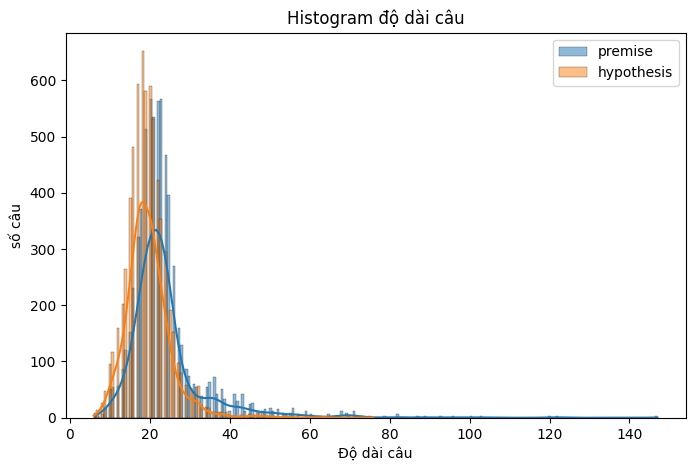

In [13]:
nli_df["premise_len"] = nli_df["premise"].apply(lambda x: len(x.split()))
nli_df["hypothesis_len"] = nli_df["hypothesis"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))

sns.histplot(nli_df["premise_len"], label="premise", kde=True)
sns.histplot(nli_df["hypothesis_len"], label="hypothesis", kde=True)

plt.legend()
plt.title("Histogram độ dài câu")
plt.xlabel("Độ dài câu")
plt.ylabel("số câu")

plt.show()

## biểu đồ phân bổ sau khi xử lý

In [14]:
sentences_clean = nli_df_clean["premise"].tolist() + nli_df_clean["hypothesis"].tolist()

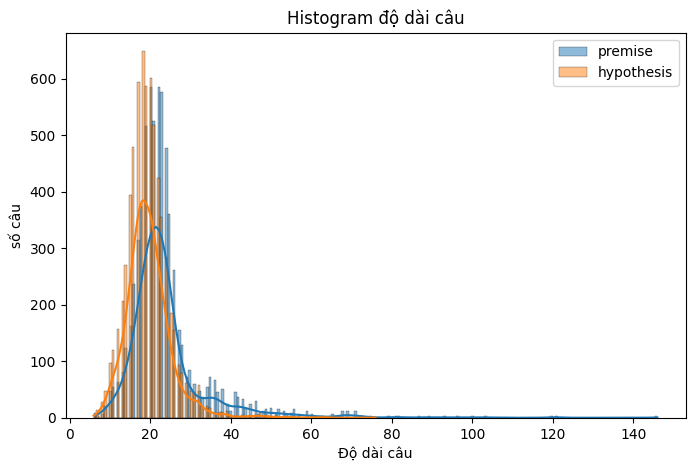

In [15]:
nli_df_clean["premise_len"] = nli_df_clean["premise"].apply(lambda x: len(x.split()))
nli_df_clean["hypothesis_len"] = nli_df_clean["hypothesis"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))

sns.histplot(nli_df_clean["premise_len"], label="premise", kde=True)
sns.histplot(nli_df_clean["hypothesis_len"], label="hypothesis", kde=True)

plt.legend()
plt.legend()
plt.title("Histogram độ dài câu")
plt.xlabel("Độ dài câu")
plt.ylabel("số câu")

plt.show()

# Tách Từ

In [16]:
!pip install vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.1 MB/s eta 0:00:00:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=5e50857262d49616592c562190ca31626093c5337a38c9ac3fe7ac318914ceea
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [17]:
# tải model 
!mkdir -p /kaggle/working/vncorenlp

!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar -P /kaggle/working/vncorenlp

--2026-03-12 23:51:44--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘/kaggle/working/vncorenlp/VnCoreNLP-1.2.jar’

VnCoreNLP-1.2.jar   100%[===================>]  26.14M  --.-KB/s    in 0.07s   

2026-03-12 23:51:47 (378 MB/s) - ‘/kaggle/working/vncorenlp/VnCoreNLP-1.2.jar’ saved [27412703/27412703]



In [18]:

!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
!unzip master.zip

--2026-03-12 23:51:47--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 4.237.22.38
Connecting to github.com (github.com)|4.237.22.38|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2026-03-12 23:51:47--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 4.237.22.35
Connecting to codeload.github.com (codeload.github.com)|4.237.22.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [       <=>          ] 160.84M  20.1MB/s    in 9.4s    

2026-03-12 23:51:57 (17.0 MB/s) - ‘master.zip’ saved [168648997]

Archive:  master.zip
62bbc58fe5d113c898eae112656be97dcf50b3a0
   creating: VnCoreNLP-master/
  inflating: VnCoreNLP-master/LICENSE.md  
  in

In [19]:
!pip install py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.4 MB/s eta 0:00:00
  Created wheel for py_vncorenlp: filename=py_vncorenlp-0.1.4-py3-none-any.whl size=4304 sha256=0b42fc5481649fb9ab982fac2953751cec640facd004db1f166ef8104a6cf512
  Stored in directory: /root/.cache/pip/wheels/db/e5/ff/f4a1b4ece36e8582db1ca71150a34e987e65df50c35974e9bb
Successfully built py_vncorenlp


## khởi tạo model vncorenlp

In [20]:
import py_vncorenlp

model_TachTu = py_vncorenlp.VnCoreNLP(
    annotators=["wseg"],
    save_dir="/kaggle/working/VnCoreNLP-master"
)

2026-03-12 23:52:05 INFO  WordSegmenter:24 - Loading Word Segmentation model


In [21]:
# xem thử 1 câu
print(sentences_clean[0])

Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành lập một trung đội 34 người mang tên Việt Nam Tuyên truyền Giải phóng quân


In [22]:
# tách từ và ưu vào tokenized_sentences
tokenized_sentences = [
    model_TachTu.word_segment(s)[0].split()
    for s in sentences_clean
]

In [23]:
# in ra câu trước và sau khi test
print(sentences_clean[100])
print(tokenized_sentences[100])
print(type(tokenized_sentences[100]))

Với sự hỗ trợ của các đồng minh xã hội chủ nghĩa bao gồm Liên Xô và Trung Quốc Quân đội nhân dân Việt Nam và Mặt trận Dân tộc Giải phóng miền Nam Việt Nam chiến đấu chống Quân lực Việt Nam Cộng hòa
['Với', 'sự', 'hỗ_trợ', 'của', 'các', 'đồng_minh', 'xã_hội_chủ_nghĩa', 'bao_gồm', 'Liên_Xô', 'và', 'Trung_Quốc', 'Quân_đội', 'nhân_dân', 'Việt_Nam', 'và', 'Mặt_trận', 'Dân_tộc', 'Giải_phóng', 'miền', 'Nam', 'Việt_Nam', 'chiến_đấu', 'chống', 'Quân_lực', 'Việt_Nam', 'Cộng_hoà']
<class 'list'>


In [24]:
df_VnCoreNLP = nli_df_clean

In [25]:
df_VnCoreNLP["premise_token"] = df_VnCoreNLP["premise"].apply(lambda x: model_TachTu.word_segment(x)[0])
df_VnCoreNLP["hypothesis_token"] = df_VnCoreNLP["hypothesis"].apply(lambda x: model_TachTu.word_segment(x)[0])

df_VnCoreNLP.head(10)

,premise,hypothesis,label,premise_len,hypothesis_len,premise_token,hypothesis_token
0,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,1,25,19,Ngày 22 tháng 12 năm 1944 Võ_Nguyên_Giáp thành...,Việt_Nam Tuyên_truyền Giải_phóng_quân được thà...
1,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,0,25,13,Ngày 22 tháng 12 năm 1944 Võ_Nguyên_Giáp thành...,Việt_Nam Tuyên_truyền Giải_phóng_quân được thà...
2,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Cuối năm 1944 phong trào vũ trang cách mạng ở ...,2,25,19,Ngày 22 tháng 12 năm 1944 Võ_Nguyên_Giáp thành...,Cuối năm 1944 phong_trào vũ_trang cách_mạng ở ...
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,1,20,22,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Việt_Nam Tuyên_truyền Giải_phóng_quân không có...
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,0,20,23,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Việt_Nam Tuyên_truyền Giải_phóng_quân là lực_l...
5,Việt Nam Tuyên truyền Giải phóng quân là một t...,Quân đội Nhân dân Việt Nam được phát triển từ ...,2,20,17,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Quân_đội Nhân_dân Việt_Nam được phát_triển từ ...
6,ngày 12 tháng 3 năm 1945 Ban Thường vụ Trung ư...,Chỉ thị được ban hành để kêu gọi hợp tác với q...,1,38,15,ngày 12 tháng 3 năm 1945 Ban Thường_vụ Trung_ư...,Chỉ_thị được ban_hành để kêu_gọi hợp_tác với q...
7,ngày 12 tháng 3 năm 1945 Ban Thường vụ Trung ư...,Tháng 3 năm 1945 Đảng Cộng sản Việt Nam đã kêu...,0,38,20,ngày 12 tháng 3 năm 1945 Ban Thường_vụ Trung_ư...,Tháng 3 năm 1945 Đảng_Cộng_sản_Việt_Nam đã kêu...
8,ngày 12 tháng 3 năm 1945 Ban Thường vụ Trung ư...,Trong năm 1945 Đảng Cộng sản Đông Dương phải đ...,2,38,19,ngày 12 tháng 3 năm 1945 Ban Thường_vụ Trung_ư...,Trong năm 1945 Đảng Cộng_sản Đông_Dương phải đ...
9,Dưới sự cai trị của Nhật từ tháng 10 năm 1944 ...,Nạn đói năm 1945 không gây thiệt hại lớn về nh...,1,27,12,Dưới sự cai_trị của Nhật từ tháng 10 năm 1944 ...,Nạn đói năm 1945 không gây thiệt_hại lớn về nh...


In [26]:
df_VnCoreNLP["premise_token"] = df_VnCoreNLP["premise_token"].apply(lambda x: x.split())
df_VnCoreNLP["hypothesis_token"] = df_VnCoreNLP["hypothesis_token"].apply(lambda x: x.split())

In [27]:
df_VnCoreNLP

,premise,hypothesis,label,premise_len,hypothesis_len,premise_token,hypothesis_token
0,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,1,25,19,"[Ngày, 22, tháng, 12, năm, 1944, Võ_Nguyên_Giá...","[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, được..."
1,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Việt Nam Tuyên truyền Giải phóng quân được thà...,0,25,13,"[Ngày, 22, tháng, 12, năm, 1944, Võ_Nguyên_Giá...","[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, được..."
2,Ngày 22 tháng 12 năm 1944 Võ Nguyên Giáp thành...,Cuối năm 1944 phong trào vũ trang cách mạng ở ...,2,25,19,"[Ngày, 22, tháng, 12, năm, 1944, Võ_Nguyên_Giá...","[Cuối, năm, 1944, phong_trào, vũ_trang, cách_m..."
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,1,20,22,"[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, là, ...","[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, khôn..."
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,0,20,23,"[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, là, ...","[Việt_Nam, Tuyên_truyền, Giải_phóng_quân, là, ..."
...,...,...,...,...,...,...,...
6712,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,0,16,14,"[Tổng_số, báo, miền, Bắc, ấn_hành, vào, năm, 1...","[Năm, 1957, tổng_số, báo, in, tại, miền, Bắc, ..."
6713,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...,2,16,19,"[Tổng_số, báo, miền, Bắc, ấn_hành, vào, năm, 1...","[Số_lượng, báo_chí, phát_hành, lớn, phản_ánh, ..."
6714,Lịch sử Việt Nam giai đoạn 19541965 là quá trì...,Lịch sử Việt Nam giai đoạn 19541965 không gắn ...,1,21,23,"[Lịch_sử, Việt_Nam, giai_đoạn, 19541965, là, q...","[Lịch_sử, Việt_Nam, giai_đoạn, 19541965, không..."
6715,Lịch sử Việt Nam giai đoạn 19541965 là quá trì...,Giai đoạn 19541965 của lịch sử Việt Nam gắn vớ...,0,21,21,"[Lịch_sử, Việt_Nam, giai_đoạn, 19541965, là, q...","[Giai_đoạn, 19541965, của, lịch_sử, Việt_Nam, ..."


# xây dựng từ vựng

In [28]:
# gộp tất cả từ lại

all_tokens = []

for sent in tokenized_sentences:
    all_tokens.extend(sent)

print(len(all_tokens))
print(all_tokens[:30])

203742
['Ngày', '22', 'tháng', '12', 'năm', '1944', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'Ngày', '22', 'tháng', '12', 'năm', '1944', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang']


In [29]:
# đếm tần số và vẽ biểu đồ

from collections import Counter

word_freq = Counter(all_tokens)

print("Top 20 frequent words:")
print(word_freq.most_common(20))

Top 20 frequent words:
[('và', 4236), ('năm', 3615), ('của', 3477), ('được', 2499), ('Việt_Nam', 2308), ('trong', 2082), ('đã', 1930), ('không', 1881), ('các', 1858), ('tại', 1842), ('là', 1764), ('Pháp', 1679), ('vào', 1591), ('cho', 1565), ('miền', 1492), ('để', 1273), ('Bắc', 1217), ('có', 1202), ('với', 1154), ('tháng', 1129)]


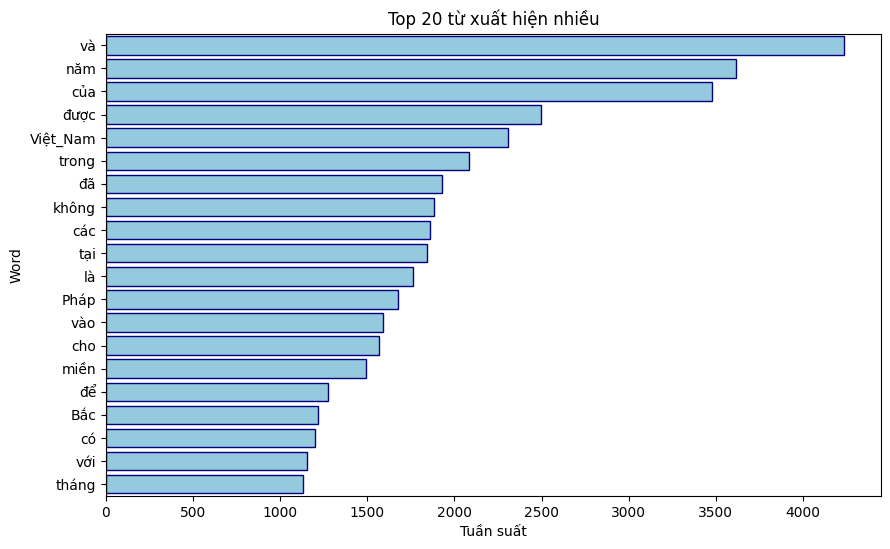

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

top_words = word_freq.most_common(20)

df = pd.DataFrame(top_words, columns=["word", "freq"])

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df, x="freq", y="word", color="skyblue")

# chỉnh màu viền
for bar in ax.patches:
    bar.set_edgecolor("navy")

plt.title("Top 20 từ xuất hiện nhiều")
plt.xlabel("Tuần suất")
plt.ylabel("Word")

plt.show()

In [31]:
# loại bỏ những từ xuất hiện dưới 2 lần
min_freq = 2

vocab_words = [word for word, freq in word_freq.items() if freq >= min_freq]


print("Vocabulary size:", len(vocab_words))

Vocabulary size: 6082


In [32]:
# sắp xếp tần số xuất hiện từ ccao đên thấp
vocab_words = sorted(
    vocab_words,
    key=lambda w: word_freq[w],
    reverse=True
)

In [33]:
vocab = ["<PAD>", "<UNK>"] + vocab_words
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

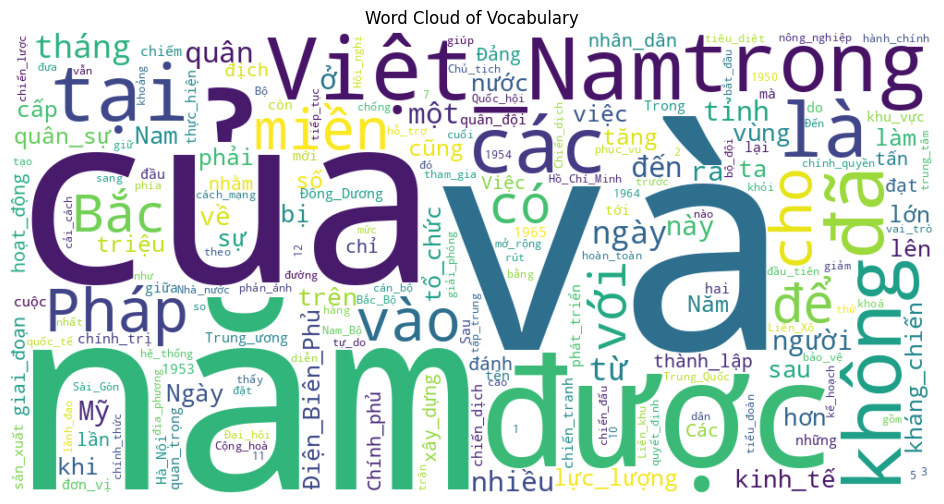

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Word Cloud of Vocabulary")
plt.show()

In [35]:
vocab_df = pd.DataFrame({
    "word": vocab,
    "index": range(len(vocab))
})

# vocab_df.to_csv("vocab.csv", index=False, encoding="utf-8")

# print("Saved vocab.csv")

In [36]:
print(vocab_df.head(50))

             word  index
0           <PAD>      0
1           <UNK>      1
2              và      2
3             năm      3
4             của      4
5            được      5
6        Việt_Nam      6
7           trong      7
8              đã      8
9           không      9
10            các     10
11            tại     11
12             là     12
13           Pháp     13
14            vào     14
15            cho     15
16           miền     16
17             để     17
18            Bắc     18
19             có     19
20            với     20
21          tháng     21
22             từ     22
23           ngày     23
24           quân     24
25            một     25
26              ở     26
27            đến     27
28          nhiều     28
29             ra     29
30           tỉnh     30
31            này     31
32          người     32
33             Mỹ     33
34             về     34
35           trên     35
36            sau     36
37           nước     37
38             ta     38


In [37]:
def encode(sentence):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in sentence]

encode(["Việt_Nam","thành_lập","quân_đội"])

[6, 63, 100]

In [38]:
[idx2word[i] for i in [5, 59, 93]]

['được', 'tổ_chức', 'Trung_ương']

In [39]:
encoded_sentences = [encode(s) for s in tokenized_sentences]


In [40]:

print(tokenized_sentences[6])
print(encoded_sentences[6])

['ngày', '12', 'tháng', '3', 'năm', '1945', 'Ban', 'Thường_vụ', 'Trung_ương', 'Đảng_Cộng_sản_Việt_Nam', 'ra', 'chỉ_thị', 'Nhật_Pháp', 'bắn', 'nhau', 'và', 'hành_động', 'của', 'chúng_ta', 'nhằm', 'phát_động', 'cao_trào', 'kháng', 'Nhật', 'cứu', 'nước']
[23, 192, 21, 125, 3, 256, 209, 917, 93, 349, 29, 1029, 5126, 427, 507, 2, 1046, 4, 2086, 64, 583, 2544, 4384, 711, 641, 37]


In [41]:
[idx2word[i] for i in [5271, 196, 901, 88, 335, 26, 1017, 5272, 411, 497, 2, 1034, 3, 2105, 60, 570, 2565, 4480, 702, 630, 33]]

['bất_khả_xâm_phạm',
 'bảo_vệ',
 '40',
 'còn',
 'hàng_hoá',
 'ở',
 'chạy',
 'Vả_lại',
 'Những',
 'đoàn',
 'và',
 'con_số',
 'năm',
 'tung',
 'cấp',
 'Đại_học',
 'ngọn',
 'xếp_hạng',
 'ngoài',
 'giao',
 'Mỹ']

# CBOW

In [42]:
window_size = 2

contexts_cbow = []
targets_cbow = []

for sentence in encoded_sentences:

    for i in range(window_size, len(sentence)-window_size):

        context_cbow = sentence[i-window_size:i] + sentence[i+1:i+window_size+1]
        target_cbow = sentence[i]

        contexts_cbow.append(context_cbow)
        targets_cbow.append(target_cbow)

print(contexts_cbow[1200])
print(targets_cbow[1200])

[10, 86, 2, 493]
1524


In [43]:
[idx2word[i] for i in [5273, 24, 824, 733]]

['dám', 'quân', 'bộ_phận', 'ngân_hàng']

In [44]:
[idx2word[i] for i in [5274]]

['đâu']

In [45]:
[idx2word[i] for i in [35, 36, 38, 23]]

['trên', 'sau', 'ta', 'ngày']

In [46]:
[idx2word[i] for i in [37]]

['nước']

In [47]:
import numpy as np
from tensorflow.keras.utils import to_categorical

vocab_size = len(word2idx)

X = np.array(contexts_cbow)
y = to_categorical(targets_cbow, num_classes=vocab_size) 

print("X shape:", X.shape)
print("y shape:", y.shape)

2026-03-12 23:55:22.061850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773359722.245311      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773359722.297365      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773359722.751671      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773359722.751715      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773359722.751718      55 computation_placer.cc:177] computation placer alr

X shape: (150006, 4)
y shape: (150006, 6084)


In [48]:
print(X[6])
print(y[6])

[ 754   63 1973 1316]
[0. 0. 0. ... 0. 0. 0.]


In [64]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, Lambda, Dense
# import tensorflow as tf

# embedding_size = 300

# model_cbow = Sequential()

# model_cbow.add(
#     Embedding(
#         input_dim=vocab_size,
#         output_dim=embedding_size,
#         input_length=2*window_size
#     )
# )

# model_cbow.add(Lambda(lambda x: tf.reduce_mean(x, axis=1)))

# model_cbow.add(Dense(vocab_size, activation="softmax"))

# model_cbow.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# model_cbow.fit(X, y, epochs=50, batch_size=256)

In [53]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [54]:
checkpoint = ModelCheckpoint(
    "cbow_attention_best.h5",   # file lưu model
    monitor="val_loss",         # theo dõi val_loss
    save_best_only=True,        # chỉ lưu model tốt nhất
    mode="min",                 # val_loss càng nhỏ càng tốt
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss",        # theo dõi val_loss
    patience=5,                # nếu 5 epoch không cải thiện thì dừng
    restore_best_weights=True, # khôi phục weight tốt nhất
    verbose=1
)

In [56]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Softmax, Multiply, Lambda
from tensorflow.keras.models import Model

embedding_size = 300
context_size = 2 * window_size

# Input layer
inputs = Input(shape=(context_size,))

# Embedding layer
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_size
)(inputs)

# Attention score
score = Dense(1)(embedding)

# Attention weights
attention_weights = Softmax(axis=1)(score)

# Apply attention
weighted_embedding = Multiply()([embedding, attention_weights])

# Sum context vectors
context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted_embedding)

# Predict target word
output = Dense(vocab_size, activation="softmax")(context_vector)

# Build model
model_cbow_attention = Model(inputs, output)

# Compile
model_cbow_attention.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
model_cbow_attention.fit(
    X,
    y,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0440 - loss: 7.6870
Epoch 1: val_loss improved from inf to 6.43424, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0440 - loss: 7.6858 - val_accuracy: 0.0882 - val_loss: 6.4342
Epoch 2/50
523/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0674 - loss: 6.2788
Epoch 2: val_loss improved from 6.43424 to 6.16943, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0675 - loss: 6.2776 - val_accuracy: 0.1085 - val_loss: 6.1694
Epoch 3/50
519/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0907 - loss: 5.8045
Epoch 3: val_loss improved from 6.16943 to 6.00256, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0908 - loss: 5.8033 - val_accuracy: 0.1186 - val_loss: 6.0026
Epoch 4/50
519/528 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1082 - loss: 5.4457
Epoch 4: val_loss improved from 6.00256 to 5.86106, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1082 - loss: 5.4447 - val_accuracy: 0.1297 - val_loss: 5.8611
Epoch 5/50
518/528 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1308 - loss: 5.1001
Epoch 5: val_loss improved from 5.86106 to 5.71662, saving model to cbow_attention_best.h5


...

528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5531 - loss: 2.1386 - val_accuracy: 0.3160 - val_loss: 4.3362
Epoch 14/50
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 1.8384
Epoch 14: val_loss improved from 4.33620 to 4.24210, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6169 - loss: 1.8383 - val_accuracy: 0.3365 - val_loss: 4.2421
Epoch 15/50
523/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6655 - loss: 1.6055
Epoch 15: val_loss improved from 4.24210 to 4.16867, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6655 - loss: 1.6054 - val_accuracy: 0.3541 - val_loss: 4.1687
Epoch 16/50
525/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7047 - loss: 1.4085
Epoch 16: val_loss improved from 4.16867 to 4.13736, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7047 - loss: 1.4085 - val_accuracy: 0.3640 - val_loss: 4.1374
Epoch 17/50
520/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7384 - loss: 1.2593
Epoch 17: val_loss improved from 4.13736 to 4.12410, saving model to cbow_attention_best.h5


528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7384 - loss: 1.2593 - val_accuracy: 0.3772 - val_loss: 4.1241
Epoch 18/50
519/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7642 - loss: 1.1257
Epoch 18: val_loss did not improve from 4.12410
528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7641 - loss: 1.1258 - val_accuracy: 0.3824 - val_loss: 4.1383
Epoch 19/50
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7831 - loss: 1.0286
Epoch 19: val_loss did not improve from 4.12410
528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7831 - loss: 1.0286 - val_accuracy: 0.3888 - val_loss: 4.1514
Epoch 20/50
522/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8063 - loss: 0.9197
Epoch 20: val_loss did not improve from 4.12410
528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8062 - loss: 0.9200 - val_accuracy: 0.3922 - val_loss: 4.1917
Epoch 21/50
516/528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8186 - loss: 0.8500
Epoch 21: val_loss did not improve from 

In [57]:
for i, layer in enumerate(model_cbow_attention.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer_3 InputLayer
1 embedding_3 Embedding
2 dense_6 Dense
3 softmax_3 Softmax
4 multiply_3 Multiply
5 lambda_3 Lambda
6 dense_7 Dense


In [58]:
embedding_layer_cbow = model_cbow_attention.layers[1]

embeddings_cbow = embedding_layer_cbow.get_weights()[0]

print(embeddings_cbow.shape)

(6084, 300)


In [70]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# pca = PCA(n_components=2)

# reduced = pca.fit_transform(embeddings_cbow)

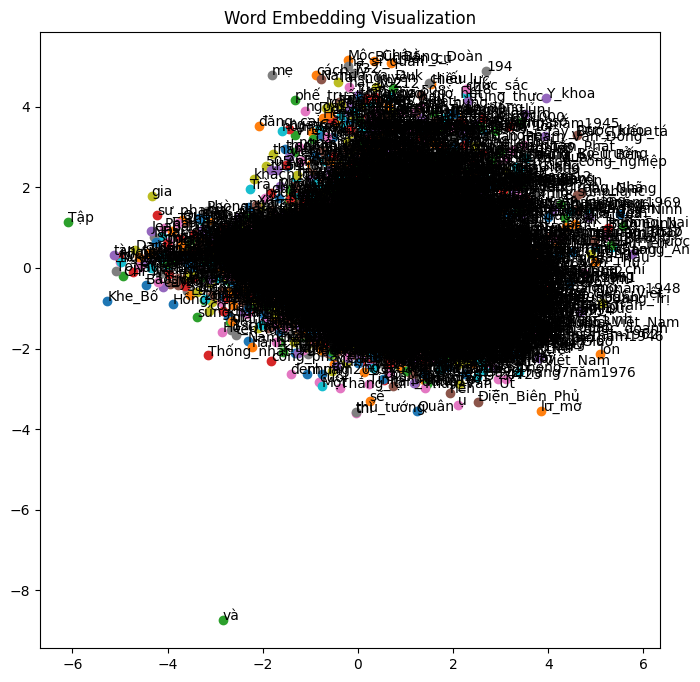

In [71]:
# plt.figure(figsize=(8,8))

# for word, idx in word2idx.items():

#     if idx >= len(reduced):
#         continue

#     x, y = reduced[idx]

#     plt.scatter(x, y)
#     plt.text(x, y, word)

# plt.title("Word Embedding Visualization")
# plt.show()

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

def most_similar_cbow(word):

    idx = word2idx[word]

    vec = embeddings_cbow[idx].reshape(1,-1)

    sims = cosine_similarity(vec, embeddings_cbow)[0]

    nearest = sims.argsort()[-10:-1][::-1]

    for i in nearest:
        print(idx2word[i], sims[i])

In [60]:
most_similar_cbow("Việt_Nam")

Trung_tâm 0.46180856
biến_đổi 0.45830613
Bộ_Tổng_Tư_lệnh 0.44301456
Khmer_Đỏ 0.43406546
nội_địa 0.42090744
Nhật_Bản 0.4086379
thoả_thuận 0.3995793
quyền_công_dân 0.3901118
Lê_Đức_Anh 0.38784948


In [61]:
most_similar_cbow("chiến_tranh")

giao_tranh 0.42359164
2541976 0.41495126
Mục_đích 0.3882624
Chiến_tranh 0.3863359
căng_thẳng 0.3826454
thảo_luận 0.36975706
đối_phó 0.36266863
nhìn_chung 0.3616998
lâu_dài 0.35486418


In [75]:
most_similar_cbow("Đại_tướng")

thực_địa 0.38149056
ngày26tháng1năm1954 0.37316436
Castor 0.33803558
Nguyễn_Văn_Linh 0.28793827
sai_lầm 0.27098474
Nhận_định 0.27062094
tên 0.26857695
cánh 0.26734805
39NQTW 0.26635957


# NLI

In [62]:
encoded_premise = [
    encode(s)
    for s in df_VnCoreNLP["premise_token"]
]


In [63]:
encoded_hypothesis = [
    encode(s)
    for s in df_VnCoreNLP["hypothesis_token"]
]

In [64]:
print(df_VnCoreNLP["premise_token"].iloc[0])
print(encoded_premise[0])

['Ngày', '22', 'tháng', '12', 'năm', '1944', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân']
[42, 1140, 21, 192, 3, 2938, 754, 63, 25, 1973, 1316, 32, 298, 90, 6, 2365, 1723]


In [65]:
[idx2word[i] for i in [165, 1, 2120, 1, 277, 1, 377, 1, 51, 1, 1, 1, 742, 59, 22, 1982, 1465, 29, 287, 86, 5, 2385, 1719]]

['bằng',
 '<UNK>',
 '64',
 '<UNK>',
 'sử_dụng',
 '<UNK>',
 'chuẩn_bị',
 '<UNK>',
 'số',
 '<UNK>',
 '<UNK>',
 '<UNK>',
 'điện',
 'tổ_chức',
 'từ',
 'Cho',
 'Đường',
 'ra',
 'chỉ_huy',
 'khu_vực',
 'được',
 'mất_tích',
 'dinh_điền']

In [68]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 60

premise_pad = pad_sequences(encoded_premise, maxlen=max_len, padding="post")
hypothesis_pad = pad_sequences(encoded_hypothesis, maxlen=max_len, padding="post")

In [69]:
print(premise_pad[0])
print(hypothesis_pad[0])

[  42 1140   21  192    3 2938  754   63   25 1973 1316   32  298   90
    6 2365 1723    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]
[   6 2365 1723    5   63   14    3  330  923   25 1197  517   13    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


In [70]:
[idx2word[i] for i in [ 2,  3 , 4 , 5 , 6 , 7 , 1 , 8 , 9 ,10 ,11 ,12 ,13 ,14 ,15 ,16 ,17 ,18 , 0 , 0 , 0 , 0 , 0 ,0 ,0,0 ,0 ,0 , 0]]

['và',
 'năm',
 'của',
 'được',
 'Việt_Nam',
 'trong',
 '<UNK>',
 'đã',
 'không',
 'các',
 'tại',
 'là',
 'Pháp',
 'vào',
 'cho',
 'miền',
 'để',
 'Bắc',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>']

In [71]:
labels = df_VnCoreNLP["label"].values

In [72]:
print(premise_pad.shape)
print(hypothesis_pad.shape)

(6717, 60)
(6717, 60)


In [73]:
labels

array([1, 0, 2, ..., 1, 0, 2])

In [74]:
embeddings_cbow.shape

(6084, 300)

In [75]:
import numpy as np

## chia train/ test

In [76]:
from sklearn.model_selection import train_test_split
X_premise_train, X_premise_test, \
X_hyp_train, X_hyp_test, \
y_train, y_test = train_test_split(
    premise_pad,
    hypothesis_pad,
    labels,
    test_size=0.2,
    random_state=42
)

# Model 1

In [78]:
# from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Concatenate
# from tensorflow.keras.models import Model

# premise_input = Input(shape=(max_len,))
# hypothesis_input = Input(shape=(max_len,))

# embedding_layer = Embedding(
#     input_dim=vocab_size,
#     output_dim=300,
#     weights=[embeddings_cbow],
#     trainable=False
# )

# p = embedding_layer(premise_input)
# h = embedding_layer(hypothesis_input)

# p = Bidirectional(LSTM(64))(p)
# h = Bidirectional(LSTM(64))(h)

# merged = Concatenate()([p,h])

# x = Dense(64, activation="relu")(merged)
# x = Dropout(0.5)(x)

# output = Dense(3, activation="softmax")(x)

# model2 = Model([premise_input, hypothesis_input], output)

# model2.compile(
#     optimizer="adam",
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [85]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [86]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(
    "best_nli_model.h5",   # tên file lưu
    monitor="val_loss",    # theo dõi val_loss
    save_best_only=True,   # chỉ lưu model tốt nhất
    mode="min",            # val_loss càng nhỏ càng tốt
    verbose=1
)

In [213]:
# model2.fit(
#     [X_premise_train, X_hyp_train],
#     y_train,
#     epochs=20,
#     batch_size=32,
#     validation_split=0.1,
#     callbacks=[checkpoint, early]
# )

Epoch 1/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9156 - loss: 0.2247
Epoch 1: val_loss improved from 0.45244 to 0.22233, saving model to best_nli_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9155 - loss: 0.2249 - val_accuracy: 0.9145 - val_loss: 0.2223
Epoch 2/20
150/152 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9413 - loss: 0.1542
Epoch 2: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9412 - loss: 0.1543 - val_accuracy: 0.8494 - val_loss: 0.3539
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9568 - loss: 0.1113
Epoch 3: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9567 - loss: 0.1114 - val_accuracy: 0.8717 - val_loss: 0.3162
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9607 - loss: 0.0974
Epoch 4: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9607 - loss: 0.0974 - val_accuracy: 0.8792 - val_loss: 0.3736


In [214]:
# loss, acc = model2.evaluate(
#     [X_premise_test, X_hyp_test],
#     y_test
# )

# print("Test Loss:", loss)
# print("Test Accuracy:", acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9185 - loss: 0.2051
Test Loss: 0.2008734494447708
Test Accuracy: 0.9203869104385376


# Model 2


In [223]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM
# from tensorflow.keras.layers import Dense, Dropout, Concatenate
# from tensorflow.keras.layers import Dot, Softmax, Lambda
# from tensorflow.keras.models import Model

In [225]:
# premise_input = Input(shape=(max_len,))
# hypothesis_input = Input(shape=(max_len,))

# embedding_layer = Embedding(
#     input_dim=vocab_size,
#     output_dim=embedding_dim,
#     weights=[embeddings_cbow],
#     trainable=False
# )

# p = embedding_layer(premise_input)
# h = embedding_layer(hypothesis_input)

# p = Bidirectional(LSTM(64, return_sequences=True))(p)
# h = Bidirectional(LSTM(64, return_sequences=True))(h)

# attention = Dot(axes=[2,2])([p, h])

# attention_p = Softmax(axis=-1)(attention)
# attention_h = Softmax(axis=1)(attention)

# p_context = Dot(axes=[2,1])([attention_p, h])
# h_context = Dot(axes=[1,1])([attention_h, p])

# p_combined = Concatenate()([p, p_context])
# h_combined = Concatenate()([h, h_context])

# p_vector = Lambda(lambda x: tf.reduce_mean(x, axis=1))(p_combined)
# h_vector = Lambda(lambda x: tf.reduce_mean(x, axis=1))(h_combined)

# merged = Concatenate()([p_vector, h_vector])

# x = Dense(128, activation="relu")(merged)
# x = Dropout(0.5)(x)

# output = Dense(3, activation="softmax")(x)

In [227]:
# model1 = Model(
#     [premise_input, hypothesis_input],
#     output
# )

# model1.compile(
#     optimizer="adam",
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [229]:
# model1.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 60, 300)   │  1,885,200 │ input_layer_19[0… │
│ (Embedding)         │                   │            │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 60, 128)   │    186,880 │ embedding_9[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 60, 128)   │    186,880 │ embedding_9[1][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_3 (Dot)         │ (None, 60, 60)    │          0 │ bidirectional_10… │
│                     │                   │            │ bidirectional_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 60, 60)    │          0 │ dot_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_5 (Softmax) │ (None, 60, 60)    │          0 │ dot_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_4 (Dot)         │ (None, 60, 128)   │          0 │ softmax_4[0][0],  │
│                     │                   │            │ bidirectional_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_5 (Dot)         │ (None, 60, 128)   │          0 │ softmax_5[0][0],  │
│                     │                   │            │ bidirectional_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 60, 256)   │          0 │ bidirectional_10… │
│ (Concatenate)       │                   │            │ dot_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 60, 256)   │          0 │ bidirectional_11… │
│ (Concatenate)       │                   │            │ dot_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 256)       │          0 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 256)       │          0 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 512)       │          0 │ lambda_5[0][0],   │
│ (Concatenate)       │                   │            │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │     65,664 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 3)         │        387 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,204,635 (12.22 MB)

 Trainable params: 439,811 (1.68 MB)

 Non-trainable params: 1,885,200 (7.19 MB)

 Optimizer params: 879,624 (3.36 MB)

In [228]:
# model1.fit(
#     [X_premise_train, X_hyp_train],
#     y_train,
#     epochs=20,
#     batch_size=32,
#     validation_split=0.1,
#     callbacks=[checkpoint, early]
# )

Epoch 1/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6032 - loss: 0.8199
Epoch 1: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6048 - loss: 0.8175 - val_accuracy: 0.8327 - val_loss: 0.4593
Epoch 2/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8496 - loss: 0.3839
Epoch 2: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8496 - loss: 0.3838 - val_accuracy: 0.8346 - val_loss: 0.4415
Epoch 3/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8896 - loss: 0.2645
Epoch 3: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8896 - loss: 0.2646 - val_accuracy: 0.8346 - val_loss: 0.4355
Epoch 4/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9294 - loss: 0.1835
Epoch 4: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9294 - loss: 0.1836 - val_accuracy: 0.8290 - val_loss:

In [231]:
# loss, acc = model1.evaluate(
#     [X_premise_test, X_hyp_test],
#     y_test
# )

# print("Test Loss:", loss)
# print("Test Accuracy:", acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8673 - loss: 0.3533
Test Loss: 0.36060062050819397
Test Accuracy: 0.8601190447807312


# model 3

In [79]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout, Concatenate
from tensorflow.keras.layers import Dot, Softmax, Lambda
from tensorflow.keras.models import Model

In [81]:
premise_input = Input(shape=(max_len,))
hypothesis_input = Input(shape=(max_len,))

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=300,
    weights=[embeddings_cbow],
    trainable=True
)

p = embedding(premise_input)
h = embedding(hypothesis_input)

encoder = Bidirectional(
    LSTM(64, return_sequences=True)
)

p_encoded = encoder(p)
h_encoded = encoder(h)

attention = Dot(axes=[2,2])([p_encoded, h_encoded])

w_p = Softmax(axis=-1)(attention)
w_h = Softmax(axis=1)(attention)

p_att = Dot(axes=[2,1])([w_p, h_encoded])
h_att = Dot(axes=[1,1])([w_h, p_encoded])

p_combined = Concatenate()([
    p_encoded,
    p_att,
    tf.keras.layers.Subtract()([p_encoded, p_att]),
    tf.keras.layers.Multiply()([p_encoded, p_att])
])

h_combined = Concatenate()([
    h_encoded,
    h_att,
    tf.keras.layers.Subtract()([h_encoded, h_att]),
    tf.keras.layers.Multiply()([h_encoded, h_att])
])

composition = Bidirectional(
    LSTM(
    128,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.3
)
)

p_comp = composition(p_combined)
h_comp = composition(h_combined)

p_avg = Lambda(lambda x: tf.reduce_mean(x, axis=1))(p_comp)
p_max = Lambda(lambda x: tf.reduce_max(x, axis=1))(p_comp)

h_avg = Lambda(lambda x: tf.reduce_mean(x, axis=1))(h_comp)
h_max = Lambda(lambda x: tf.reduce_max(x, axis=1))(h_comp)

merged = Concatenate()([
    p_avg,
    p_max,
    h_avg,
    h_max
])

x = Dense(256, activation="relu")(merged)
x = Dropout(0.5)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(3, activation="softmax")(x)

model = Model(
    [premise_input, hypothesis_input],
    output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [82]:
model3 = Model(
    [premise_input, hypothesis_input],
    output
)

model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
model3.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 60, 300)   │  1,825,200 │ input_layer_10[0… │
│ (Embedding)         │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 60, 128)   │    186,880 │ embedding_5[0][0… │
│ (Bidirectional)     │                   │            │ embedding_5[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 60, 60)    │          0 │ bidirectional_2[… │
│                     │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 60, 60)    │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_5 (Softmax) │ (None, 60, 60)    │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 60, 128)   │          0 │ softmax_4[0][0],  │
│                     │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 60, 128)   │          0 │ softmax_5[0][0],  │
│                     │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 60, 128)   │          0 │ bidirectional_2[… │
│                     │                   │            │ dot_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 60, 128)   │          0 │ bidirectional_2[… │
│ (Multiply)          │                   │            │ dot_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 60, 128)   │          0 │ bidirectional_2[… │
│ (Subtract)          │                   │            │ dot_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 60, 128)   │          0 │ bidirectional_2[… │
│ (Multiply)          │                   │            │ dot_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 60, 512)   │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ dot_1[0][0],      │
│                     │                   │            │ subtract[0][0],   │
│                     │                   │            │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 60, 512)   │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ dot_2[0][0],      │
│                     │                   │            │ subtract_1[0][0], │
│                     │                   │            │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 60, 256)   │    656,384 │ concatenate_1[0]… │
│ (Bidirectional)     │                   │            │ concatenate_2[0]

 Total params: 2,947,507 (11.24 MB)

 Trainable params: 2,947,507 (11.24 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model3.fit(
    [X_premise_train, X_hyp_train],
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[checkpoint, early]
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.6135 - loss: 0.7742
Epoch 1: val_loss improved from inf to 0.40180, saving model to best_nli_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 95s 523ms/step - accuracy: 0.6143 - loss: 0.7730 - val_accuracy: 0.8569 - val_loss: 0.4018
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.8689 - loss: 0.3343
Epoch 2: val_loss improved from 0.40180 to 0.33401, saving model to best_nli_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 77s 509ms/step - accuracy: 0.8689 - loss: 0.3342 - val_accuracy: 0.8773 - val_loss: 0.3340
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9200 - loss: 0.2243
Epoch 3: val_loss did not improve from 0.33401
152/152 ━━━━━━━━━━━━━━━━━━━━ 77s 508ms/step - accuracy: 0.9199 - loss: 0.2243 - val_accuracy: 0.8773 - val_loss: 0.4232
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9479 - loss: 0.1474
Epoch 4: val_loss did not improve from 0.33401
152/152 ━━━━━━━━━━━━━━━━━━━━ 78s 511ms/step - accuracy: 0.9478 - loss: 0.1475 - val_accuracy: 0.8587 - val_loss: 0.5088
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9614 - loss: 0.1191
Epoch 5: val_loss did not improve from 0.33401
152/152 ━━━━━━━━━━━━━━━━━━━━ 77s 507ms/step - accuracy: 0.9614 - loss: 0.1191 - val_accuracy: 0.8364 - val_loss: 0.6975


In [88]:
loss, acc = model3.evaluate(
    [X_premise_test, X_hyp_test],
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.8967 - loss: 0.2750
Test Loss: 0.2766226530075073
Test Accuracy: 0.8995535969734192


42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step


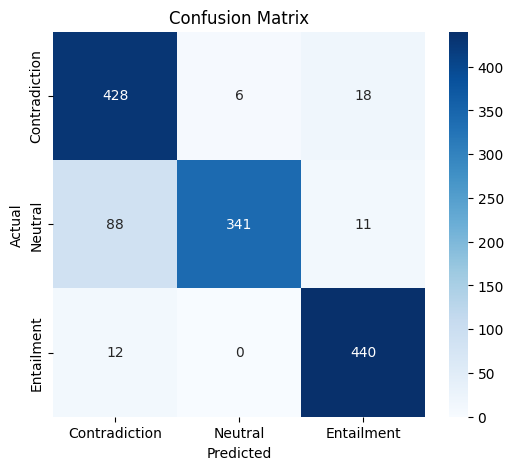

In [89]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model3.predict([X_premise_test, X_hyp_test])
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Contradiction","Neutral","Entailment"],
            yticklabels=["Contradiction","Neutral","Entailment"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# model 4


In [292]:
# import tensorflow as tf
# from tensorflow.keras.layers import (
#     Input, Embedding, Dense, Dropout, Concatenate,
#     Softmax, Dot, Lambda, Bidirectional, LSTM,
#     LayerNormalization, MultiHeadAttention
# )
# from tensorflow.keras.models import Model


# def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):

#     attn = MultiHeadAttention(
#         num_heads=num_heads,
#         key_dim=head_size
#     )(x, x)

#     attn = Dropout(dropout)(attn)
#     x = LayerNormalization(epsilon=1e-6)(x + attn)

#     ffn = Dense(ff_dim, activation="relu")(x)
#     ffn = Dense(x.shape[-1])(ffn)

#     ffn = Dropout(dropout)(ffn)
#     x = LayerNormalization(epsilon=1e-6)(x + ffn)

#     return x

In [297]:
# premise_input = Input(shape=(max_len,))
# hypothesis_input = Input(shape=(max_len,))

# embedding = Embedding(
#     input_dim=vocab_size,
#     output_dim=embedding_dim,
#     weights=[embeddings_cbow],
#     trainable=False
# )

# # embedding
# p = embedding(premise_input)
# h = embedding(hypothesis_input)

# # transformer encoder
# p_encoded = transformer_block(p, 64, 4, 128)
# h_encoded = transformer_block(h, 64, 4, 128)

# # cross attention
# attention = Dot(axes=[2, 2])([p_encoded, h_encoded])

# w_p = Softmax(axis=-1)(attention)
# w_h = Softmax(axis=1)(attention)

# p_att = Dot(axes=[2, 1])([w_p, h_encoded])
# h_att = Dot(axes=[1, 1])([w_h, p_encoded])

# # inference features
# p_combined = Concatenate()([
#     p_encoded,
#     p_att,
#     tf.keras.layers.Subtract()([p_encoded, p_att]),
#     tf.keras.layers.Multiply()([p_encoded, p_att])
# ])

# h_combined = Concatenate()([
#     h_encoded,
#     h_att,
#     tf.keras.layers.Subtract()([h_encoded, h_att]),
#     tf.keras.layers.Multiply()([h_encoded, h_att])
# ])

# # composition layer
# composition = Bidirectional(
#     LSTM(
#         128,
#         return_sequences=True,
#         dropout=0.3,
#         recurrent_dropout=0.3
#     )
# )

# p_comp = composition(p_combined)
# h_comp = composition(h_combined)

# # pooling
# p_avg = Lambda(lambda x: tf.reduce_mean(x, axis=1))(p_comp)
# p_max = Lambda(lambda x: tf.reduce_max(x, axis=1))(p_comp)

# h_avg = Lambda(lambda x: tf.reduce_mean(x, axis=1))(h_comp)
# h_max = Lambda(lambda x: tf.reduce_max(x, axis=1))(h_comp)

# merged = Concatenate()([
#     p_avg,
#     p_max,
#     h_avg,
#     h_max
# ])

# # classifier
# x = Dense(256, activation="relu")(merged)
# x = Dropout(0.5)(x)

# x = Dense(64, activation="relu")(x)
# x = Dropout(0.5)(x)

# output = Dense(3, activation="softmax")(x)

# # model
# model4 = Model(
#     inputs=[premise_input, hypothesis_input],
#     outputs=output
# )

# model4.compile(
#     optimizer="adam",
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# model4.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_36      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 60, 300)   │  1,885,200 │ input_layer_35[0… │
│ (Embedding)         │                   │            │ input_layer_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 300)   │    308,268 │ embedding_17[0][… │
│ (MultiHeadAttentio… │                   │            │ embedding_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 300)   │    308,268 │ embedding_17[1][… │
│ (MultiHeadAttentio… │                   │            │ embedding_17[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 60, 300)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 60, 300)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 60, 300)   │          0 │ embedding_17[0][… │
│                     │                   │            │ dropout_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 60, 300)   │          0 │ embedding_17[1][… │
│                     │                   │            │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 300)   │        600 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 300)   │        600 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 60, 128)   │     38,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 60, 128)   │     38,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 60, 300)   │     38,700 │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 60, 300)   │     38,700 │ dense_54[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 60, 300)   │          0 │ dense_53[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 60, 300)   │          0 │ dense_55[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 60, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_40[0][0]

 Total params: 4,298,531 (16.40 MB)

 Trainable params: 2,413,331 (9.21 MB)

 Non-trainable params: 1,885,200 (7.19 MB)

In [298]:
# model4.fit(
#     [X_premise_train, X_hyp_train],
#     y_train,
#     epochs=20,
#     batch_size=32,
#     validation_split=0.1,
#     callbacks=[checkpoint, early]
# )

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.3713 - loss: 1.1485
Epoch 1: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 96s 530ms/step - accuracy: 0.3718 - loss: 1.1477 - val_accuracy: 0.6450 - val_loss: 0.6271
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.7433 - loss: 0.5728
Epoch 2: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 79s 518ms/step - accuracy: 0.7436 - loss: 0.5724 - val_accuracy: 0.8532 - val_loss: 0.4128
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8497 - loss: 0.3910
Epoch 3: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 79s 517ms/step - accuracy: 0.8497 - loss: 0.3910 - val_accuracy: 0.8587 - val_loss: 0.4049
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8690 - loss: 0.3558
Epoch 4: val_loss did not improve from 0.22233
152/152 ━━━━━━━━━━━━━━━━━━━━ 79s 517ms/step - accuracy: 0.8689 - loss: 0.3559 - val_accuracy: 0.8513

In [299]:
# loss, acc = model3.evaluate(
#     [X_premise_test, X_hyp_test],
#     y_test
# )

# print("Test Loss:", loss)
# print("Test Accuracy:", acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8916 - loss: 0.3098
Test Loss: 0.30800557136535645
Test Accuracy: 0.8809523582458496


# Load Model

In [94]:
# from tensorflow.keras.models import load_model

# model3 = load_model("/kaggle/working/VnCoreNLP-master/best_nli_model.h5")

In [102]:
def predict_nli(premise, hypothesis):

    
    p = preprocess_text(premise)
    h = preprocess_text(hypothesis)

    # print(p)
    # print(h)
    
    p = model_TachTu.word_segment(p)[0].split()
    h = model_TachTu.word_segment(h)[0].split()

    # print(p)
    # print(h)

    p = encode(p)
    h = encode(h)

    from tensorflow.keras.preprocessing.sequence import pad_sequences

    p = pad_sequences([p], maxlen=max_len, padding="post")
    h = pad_sequences([h], maxlen=max_len, padding="post")

    pred = model3.predict([p,h])

    label = np.argmax(pred)

    print(pred)
    labels_map = {
        0:"entailment",
        1:"contradiction",
        2:"neutral"
    }

   
    print("Prediction:", labels_map[label])

In [104]:
predict_nli(
    "Võ Nguyên Giáp thành lập Quân đội nhân dân Việt Nam",
    "Quân đội Việt Nam do Võ Nguyên Giáp thành lập"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
[[0.692045   0.25840098 0.04955404]]
Prediction: entailment


In [105]:
predict_nli(
    "Việt Nam tuyên bố độc lập năm 1945",
    "Việt Nam vẫn là thuộc địa của Pháp"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
[[0.40248987 0.28867158 0.3088385 ]]
Prediction: entailment


In [106]:
predict_nli(
    "Việt Nam tuyên bố độc lập năm 1945",
    "Việt Nam trở thành một quốc gia độc lập"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
[[0.19096787 0.10087746 0.7081546 ]]
Prediction: neutral


In [305]:
# predict_nli(
#     "",
#     ""
# )

In [107]:
predict_nli(
    "Ngày 31 tháng 8 năm 1858, Hải quân Pháp đổ bộ tấn công vào cảng Đà Nẵng và sau đó rút vào xâm chiếm Sài Gòn.",
    "Hải quân Pháp không tấn công Đà Nẵng mà tiến thẳng vào Huế vào năm 1858."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
[[8.7338893e-05 9.9991024e-01 2.3378427e-06]]
Prediction: contradiction


In [108]:
predict_nli(
    "Chủ tịch Hồ Chí Minh sinh ngày 19 tháng 5 năm 1890 tại xã Kim Liên, huyện Nam Đàn, tỉnh Nghệ An.",
    "Hồ Chí Minh sinh năm 1890 tại Nghệ An."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
[[0.6415306  0.24762037 0.11084913]]
Prediction: entailment


In [110]:
predict_nli(
    "Chủ tịch Hồ Chí Minh sinh ngày 19 tháng 5 năm 1890 tại xã Kim Liên, huyện Nam Đàn, tỉnh Nghệ An.",
    "Hồ Chí Minh là người sáng lập Đảng Cộng sản Việt Nam."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
[[0.8696766  0.10551272 0.02481069]]
Prediction: entailment
